<a href="https://colab.research.google.com/github/albvieiraa/Data-Analysis-Bootcamp-WoMakersCode/blob/main/estatistica_correlacao_regressao_individual_maryllianvieira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correlação e Regressão Simples/Multivariada - Desafio Final

* Aluna: Maryllian de Albuquerque Vieira

* Squad Hedy Lamar

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importando bibliotecas
import pandas            as pd
import numpy             as np
import statsmodels.api   as sm
import matplotlib.pyplot as plt
import seaborn           as sns
import scipy.stats       as stats

# Parte 01


Considerando a base de dados kc_house_data.csv responda as questões de 1 a 6

In [ ]:
# Criando df
df_house = pd.read_csv('/content/drive/MyDrive/Womakerscode - bootcamp/Arquivos/kc_house_data.csv')
df_house.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,n,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,n,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,n,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,n,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# Informações do df
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             9999 non-null   int64  
 1   date           9999 non-null   object 
 2   price          9999 non-null   float64
 3   bedrooms       9999 non-null   int64  
 4   bathrooms      9999 non-null   float64
 5   sqft_living    9999 non-null   int64  
 6   sqft_lot       9999 non-null   int64  
 7   floors         9999 non-null   float64
 8   waterfront     9999 non-null   object 
 9   view           9999 non-null   int64  
 10  condition      9999 non-null   int64  
 11  grade          9999 non-null   int64  
 12  sqft_above     9999 non-null   int64  
 13  sqft_basement  9999 non-null   int64  
 14  yr_built       9999 non-null   int64  
 15  yr_renovated   9999 non-null   int64  
 16  zipcode        9999 non-null   int64  
 17  lat            9999 non-null   float64
 18  long    

In [ ]:
# Verificando valores nulos
house_na = df_house.isna().sum()
house_na

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [ ]:
# Estatística descritiva das variáveis numéricas
df_house.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,9.999000e+03,9.999000e+03,9999.000000,9999.000000,9999.000000,9.999000e+03,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,4.549550e+09,5.334366e+05,3.361636,2.061806,2053.088209,1.603696e+04,1.432043,0.238824,3.446345,7.594459,1749.596360,303.491849,1967.274427,91.642364,98077.970297,47.559852,-122.214626,1975.779178,13359.446945
std,2.863859e+09,3.770547e+05,0.916079,0.766884,911.227082,4.504326e+04,0.511869,0.766738,0.666322,1.165901,810.917694,450.852334,27.988987,417.830430,53.943113,0.140048,0.139017,672.264191,27316.491648
min,1.000102e+06,7.500000e+04,0.000000,0.000000,380.000000,5.720000e+02,1.000000,0.000000,1.000000,3.000000,380.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.515000,620.000000,660.000000
25%,2.114001e+09,3.150000e+05,3.000000,1.500000,1410.000000,5.427500e+03,1.000000,0.000000,3.000000,7.000000,1180.000000,0.000000,1950.000000,0.000000,98032.000000,47.461950,-122.326000,1490.000000,5417.500000
50%,3.905010e+09,4.458380e+05,3.000000,2.000000,1890.000000,7.920000e+03,1.000000,0.000000,3.000000,7.000000,1530.000000,0.000000,1969.000000,0.000000,98065.000000,47.573100,-122.231000,1830.000000,7848.000000
75%,7.272001e+09,6.399500e+05,4.000000,2.500000,2500.000000,1.117550e+04,2.000000,0.000000,4.000000,8.000000,2130.000000,600.000000,1990.000000,0.000000,98118.000000,47.679400,-122.126500,2340.000000,10374.500000
max,9.842301e+09,7.700000e+06,11.000000,8.000000,12050.000000,1.651359e+06,3.500000,4.000000,5.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,5790.000000,871200.000000


In [ ]:
# Variáveis categóricas
df_house.select_dtypes(include='object').nunique()

,0
date,351
waterfront,2


## Questão 01


1. Codifique e exiba a matriz de correlação entre as variáveis numéricas. Além disso, qual é a correlação entre o preço price e o número de quartos bedrooms? Existe alguma diferença na correlação quando consideramos apenas casas com uma área total sqft_living superior a 2000 pésquadrados?

In [ ]:
# Selecionando variáveis numéricas
df_house_num = df_house.select_dtypes(include=['float64', 'int64'])

# Calculando matriz de correlação
corr_matrix = df_house_num.corr()
corr_matrix

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,0.005779,0.013855,0.007435,0.000415,-0.132510,0.012260,0.035295,-0.021744,0.012872,-0.007168,0.013732,0.011701,-0.015580,0.001720,0.000568,0.000084,-0.004075,-0.146583
price,0.005779,1.000000,0.299207,0.521193,0.702199,0.090720,0.276954,0.398731,0.044596,0.651100,0.607763,0.326087,0.036116,0.142752,-0.054596,0.297156,0.015786,0.583287,0.086809
bedrooms,0.013855,0.299207,1.000000,0.539449,0.573915,0.028929,0.213565,0.090767,0.023435,0.360955,0.464872,0.323817,0.164852,0.027509,-0.146440,0.001749,0.110417,0.376492,0.019946
bathrooms,0.007435,0.521193,0.539449,1.000000,0.764810,0.091268,0.494247,0.205681,-0.089029,0.660915,0.686311,0.311352,0.479104,0.070821,-0.204979,0.027687,0.217447,0.579341,0.099278
sqft_living,0.000415,0.702199,0.573915,0.764810,1.000000,0.167809,0.392802,0.293149,-0.047375,0.763526,0.869266,0.457630,0.324383,0.068572,-0.191899,0.062404,0.217292,0.750315,0.192839
sqft_lot,-0.132510,0.090720,0.028929,0.091268,0.167809,1.000000,0.021320,0.064464,-0.019324,0.121719,0.184876,0.006639,0.088609,-0.003411,-0.126821,-0.069145,0.225961,0.158669,0.690367
floors,0.012260,0.276954,0.213565,0.494247,0.392802,0.021320,1.000000,0.062255,-0.217362,0.463982,0.572961,-0.236646,0.405597,0.041302,-0.081076,0.042355,0.154666,0.327327,0.024016
view,0.035295,0.398731,0.090767,0.205681,0.293149,0.064464,0.062255,1.000000,0.044662,0.255709,0.174683,0.278300,-0.038961,0.113521,0.072961,-0.003913,-0.081587,0.289678,0.044554
condition,-0.021744,0.044596,0.023435,-0.089029,-0.047375,-0.019324,-0.217362,0.044662,1.000000,-0.126440,-0.144689,0.164491,-0.313085,-0.074973,-0.005119,-0.016654,-0.105288,-0.088211,-0.025178
grade,0.012872,0.651100,0.360955,0.660915,0.763526,0.121719,0.463982,0.255709,-0.126440,1.000000,0.760978,0.174460,0.438903,0.036942,-0.194369,0.111048,0.205292,0.731650,0.140770


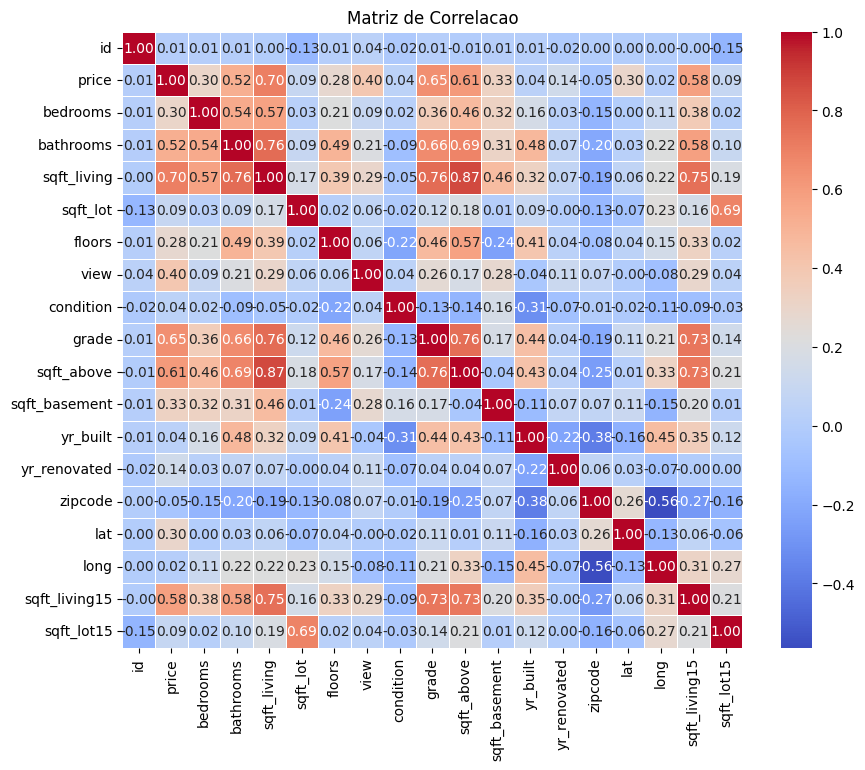

In [ ]:
# Exibindo a matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlacao')
plt.show()

A correlação entre 'price' e 'bedrooms' é **positiva fraca (0.30)**. Ou seja, quanto maior o número de quartos, maior o preço do imóvel, mesmo que essa correlação não seja forte.

In [ ]:
# Filtro onde sqft_living > a 2000 pésquadrados
df_house_2000 = df_house_num[df_house_num['sqft_living'] > 2000]

# Correlação entre 'price' e 'bedrooms' com filtro
corr_price_sqft_living = df_house_2000[['price', 'bedrooms']].corr()
corr_price_sqft_living

,price,bedrooms
price,1.000000,0.119121
bedrooms,0.119121,1.000000


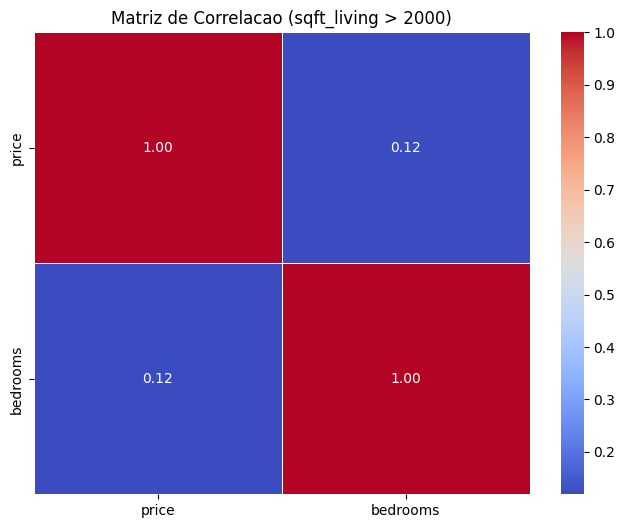

In [ ]:
# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_price_sqft_living, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlacao (sqft_living > 2000)')
plt.show()

Observando a matrix de correlação, é possível observar que considerando apenas imóveis com uma área total superior a 2000 pés quadrados, o coeficiente de correlação entre o preço e o número de quartos é ainda menor (0.12). Ou seja, a correlação entre o preço e número de quartos é mais fraca para imóveis com maior área.

## Questão 02

2. Existe alguma correlação entre o preço price e a área total da casa sqft_living, considerando apenas casas com pelo menos dois banheiros bathrooms?

In [ ]:
# Filtro bathrooms >= 2
df_house_bath = df_house_num[df_house_num['bathrooms'] >= 2]

# Correlação entre 'price' e 'sqft_living' com filtro
corr_price_sqft_living = df_house_bath[['price', 'sqft_living']].corr()
corr_price_sqft_living

,price,sqft_living
price,1.000000,0.706711
sqft_living,0.706711,1.000000


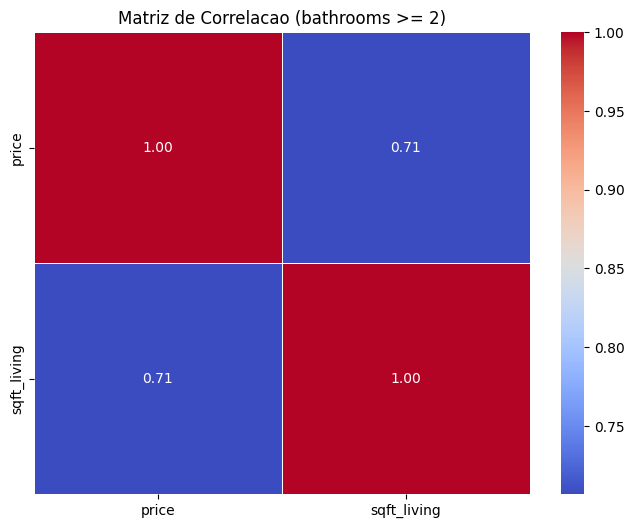

In [ ]:
# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_price_sqft_living, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlacao (bathrooms >= 2)')
plt.show()

A correlação entre preço e tamanho do imóvel com mais de dois banheiros é **positiva forte (0.71)**. Isso indica uma influência maior da área total no preço dos imóveis com mais banheiros.

## Questão 03

3. Como a quantidade de banheiros bathrooms influencia na correlação entre a área total da casa sqft_living e o preço price?

In [ ]:
# Verificando a correlação
corr_bathrooms_sqft_living_price = df_house[['price', 'sqft_living', 'bathrooms']].corr()
corr_bathrooms_sqft_living_price

,price,sqft_living,bathrooms
price,1.000000,0.702199,0.521193
sqft_living,0.702199,1.000000,0.764810
bathrooms,0.521193,0.764810,1.000000


Text(0.5, 1.0, 'Matriz de Correlação')

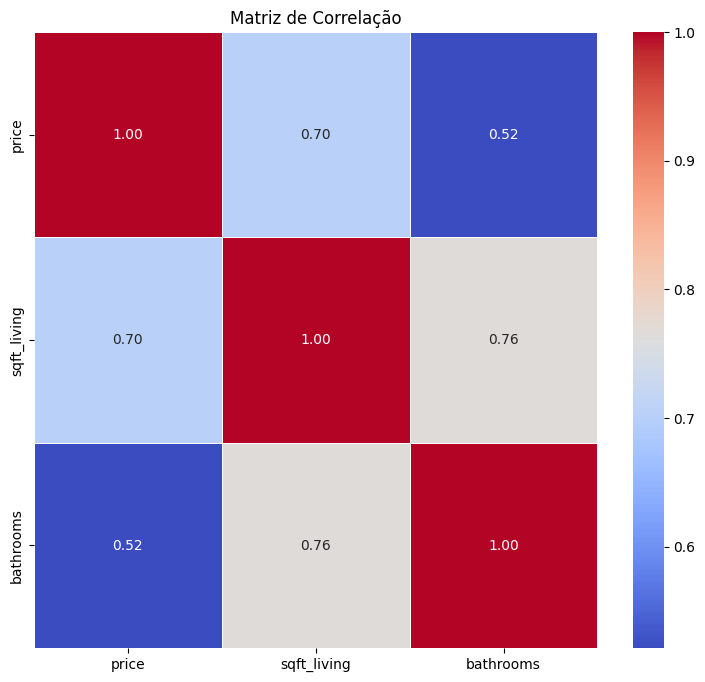

In [ ]:
# Plot - Correlação Geral
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
sns.heatmap(corr_bathrooms_sqft_living_price, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação')

A princípio é possível observar que há uma **correlação positiva forte (0.70)** entre o preço e a área do imóvel, assim como entre o preço e a quantidade de banheiros **(0.52)**. Contudo, buscando verificar mais a fundo essa correlação, decidi criar grupos a partir da quantidade de banheiros.

In [ ]:
# Verificando a quantidade de banheiros do 'bathroom'
df_house['bathrooms'].value_counts()

,count
bathrooms,
2.50,2290
1.00,1945
1.75,1502
2.00,955
2.25,938
1.50,713
2.75,534
3.00,332
3.50,270


In [ ]:
# Novo dataframe para evitar modificações no original
df_bathrooms = df_house.copy()

In [ ]:
# Criando 3 agrupamentos por banheiro a partir dos intervalos: 0-2, 2-4, 4-7
bins = [0, 2, 4, 7]

In [ ]:
df_bathrooms['bathroom_group'] = pd.cut(df_bathrooms['bathrooms'], bins=bins,
                                         labels=['Group 1', 'Group 2', 'Group 3'])

In [ ]:
df_bathrooms.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,bathroom_group
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,n,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,Group 1
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,Group 2
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,n,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,Group 1
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,n,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,Group 2
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,n,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,Group 1


In [ ]:
# Calcula matriz de correlação agrupada

bathrooms_groups = df_bathrooms.groupby('bathroom_group')
corr_bathrooms_groups = bathrooms_groups[['sqft_living', 'price']].corr()

<ipython-input-25-22f2816cc1c8>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bathrooms_groups = df_bathrooms.groupby('bathroom_group')


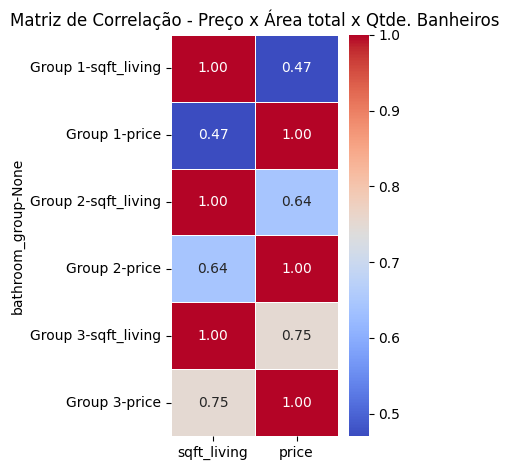

In [ ]:
# Plot - Correlação Agrupada
plt.subplot(1, 2, 2)
sns.heatmap(corr_bathrooms_groups, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação - Preço x Área total x Qtde. Banheiros')

plt.tight_layout()
plt.show()

A partir da matriz de correlação referente a quantidade de banheiros, nota-se à medida que a quantidade de banheiros aumenta, a correlação entre o preço e a área total tende a aumentar também.

## Questão 04

4. Qual é a relação entre a condição da casa condition e o preço price, considerando apenas casas com uma área total sqft_living superior a 3000 pésquadrados?

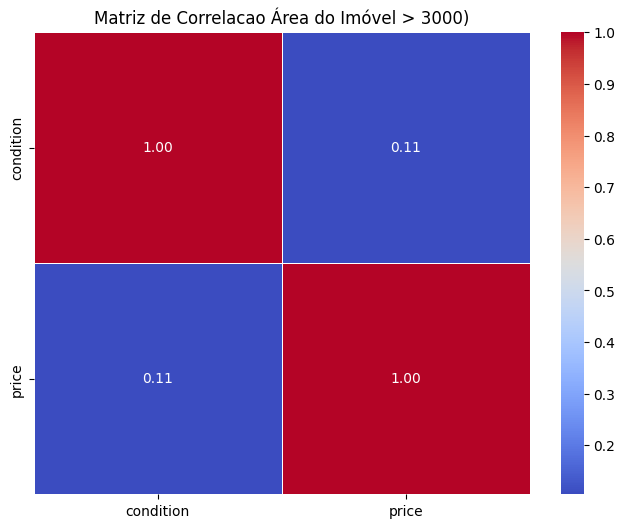

In [ ]:
# Filtro para 'sqft_living' > 3000 pésquadrados
df_house_3000 = df_house_num[df_house_num['sqft_living'] > 3000]

# Correlação entre 'condition' e 'price' com filtro
corr_condition_price = df_house_3000[['condition', 'price']].corr()

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_condition_price, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlacao Área do Imóvel > 3000)')
plt.show()

É possível obervar que há uma **correlação positiva fraca (0.11)** entre a condição e preço do imóvel com mais de 3000 pésquadrados.

## Questão 05

5. Existe alguma correlação entre a localização geográfica lat e long e o preço price para casas com pelo menos três quartos bedrooms?

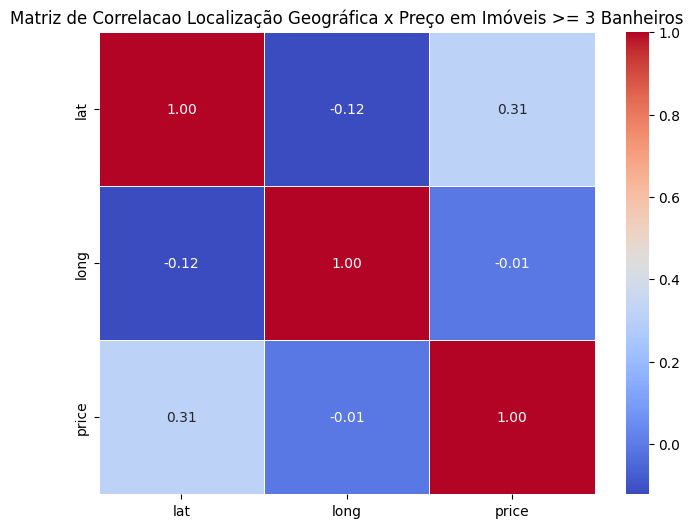

In [ ]:
# Filtro de quartos >= 3
df_house_bedrooms = df_house_num[df_house_num['bedrooms'] >= 3]

# Correlação entre 'lat' e 'long' e 'price'
corr_lat_long_price = df_house_bedrooms[['lat', 'long', 'price']].corr()

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_lat_long_price, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlacao Localização Geográfica x Preço em Imóveis >= 3 Banheiros')
plt.show()

Ao analisar a matriz de correlação considerando imóveis com pelo menos 3 quartos, observa-se que a relação entre as localização geográficas do imóvel (latitude e longitude) e o preço é fraca. Sendo a correlação com a latitude **positiva fraca (0.31)** e com a longitute **negativa fraca (-0.01)**.

## Questão 06

6. Calcule a correlação entre uma variável categórica(waterfront) e uma variável numérica(price) usando ANOVA.

In [ ]:
# Verificando as categorias de 'waterfront'
df_house['waterfront'].value_counts()

,count
waterfront,
n,9920
y,79


In [ ]:
# Criando categorias para 'waterfront'
waterfront_yes = df_house[df_house['waterfront'] == 'y']['price']
waterfront_no = df_house[df_house['waterfront'] == 'n']['price']

In [ ]:
# Teste ANOVA
f_stat, p_value = stats.f_oneway(waterfront_yes, waterfront_no)

# Resultados
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.2f}")

# # Visualização do teste
if p_value < 0.05:
    print("Rejeitamos a hipótese nula. O preço está relacionado com o fator beira-mar.")
else:
    print("Não rejeitamos a hipótese nula. Não podemos afirmar se os preços estão relacionados com o fator beira-mar.")

F-statistic: 964.57
p-value: 0.00
Rejeitamos a hipótese nula. O preço está relacionado com o fator beira-mar.


# Parte 02

Considerando a base de dados car_price.csv responda as questões de 7 a 11

In [ ]:
# Criando df
df_car = pd.read_csv('/content/drive/MyDrive/Womakerscode - bootcamp/Arquivos/car_price.csv')
df_car.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [ ]:
# Informações
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   object 
 1   Model               1874 non-null   object 
 2   Price               1874 non-null   int64  
 3   Year                1874 non-null   int64  
 4   Kilometer           1874 non-null   int64  
 5   Fuel Type           1874 non-null   object 
 6   Transmission        1874 non-null   object 
 7   Location            1874 non-null   object 
 8   Color               1874 non-null   object 
 9   Owner               1874 non-null   object 
 10  Seller Type         1874 non-null   object 
 11  Engine              1874 non-null   object 
 12  Max Power           1874 non-null   object 
 13  Max Torque          1874 non-null   object 
 14  Drivetrain          1874 non-null   object 
 15  Length              1874 non-null   float64
 16  Width 

In [ ]:
# Estatística descritiva das variáveis numéricas
df_car.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,1.874000e+03,1874.000000,1.874000e+03,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000
mean,1.718279e+06,2016.713447,5.317814e+04,4281.512807,1767.886339,1588.967983,5.295091,52.217343
std,2.426090e+06,3.138477,5.878833e+04,436.220747,131.344883,134.627659,0.807008,15.167250
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1213.000000,2.000000,15.000000
25%,5.000000e+05,2015.000000,2.801975e+04,3985.000000,1695.000000,1485.000000,5.000000,42.000000
50%,8.424995e+05,2017.000000,4.879750e+04,4360.000000,1770.000000,1544.000000,5.000000,50.000000
75%,1.908250e+06,2019.000000,7.100000e+04,4620.000000,1831.000000,1670.750000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [ ]:
# Descrição das variáveis categóricas
df_car.describe(include='object')

,Make,Model,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain
count,1874,1874,1874,1874,1874,1874,1874,1874,1874,1874,1874,1874
unique,32,955,7,2,75,16,4,3,104,309,264,3
top,Maruti Suzuki,X1 sDrive20d xLine,Diesel,Manual,Mumbai,White,First,Individual,1197 cc,89 bhp @ 4000 rpm,200 Nm @ 1750 rpm,FWD
freq,398,15,954,1037,302,727,1504,1816,230,90,90,1319


In [ ]:
# Verificação das categorias
for column in df_car.select_dtypes(include='object'):
    print(f"Valores únicos em '{column}':")
    print(df_car[column].unique())
    print()

Valores únicos em 'Make':
['Honda' 'Maruti Suzuki' 'Hyundai' 'Toyota' 'BMW' 'Skoda' 'Nissan'
 'Renault' 'Tata' 'Volkswagen' 'Ford' 'Mercedes-Benz' 'Audi' 'Mahindra'
 'MG' 'Jeep' 'Porsche' 'Kia' 'Land Rover' 'Volvo' 'Maserati' 'Jaguar'
 'Isuzu' 'MINI' 'Ferrari' 'Mitsubishi' 'Datsun' 'Chevrolet' 'Ssangyong'
 'Fiat' 'Rolls-Royce' 'Lexus']

Valores únicos em 'Model':
['Amaze 1.2 VX i-VTEC' 'Swift DZire VDI' 'i10 Magna 1.2 Kappa2' 'Glanza G'
 'Innova 2.4 VX 7 STR [2016-2020]' 'Ciaz ZXi' 'X1 xDrive20d M Sport'
 'Octavia 1.8 TSI Style Plus AT [2017]' 'Terrano XL (D)'
 'Elite i20 Sportz 1.2' 'Kwid 1.0 RXT [2016-2019]'
 'Ciaz Alpha Hybrid 1.5 AT [2018-2020]' 'Harrier XZ [2019-2020]'
 'Polo GT TSI' 'Celerio ZXi AMT [2019-2020]' 'Alto 800 LXi (O)'
 'Baleno Alpha Automatic' 'Wagon R ZXi 1.2 AMT' 'Creta 1.6 E Petrol'
 'S-Presso VXi AMT' 'Vento Comfortline Petrol AT'
 'Santro Sportz AMT [2018-2020]' 'Venue SX 1.0 (O) Petrol [2019-2020]'
 'Alto LXi CNG' 'Ritz Zxi BS-IV' 'Creta 1.6 SX Plus Petrol' 'Br

## Questão 07

7. Codifique e exiba a Matriz de correlação para as variáveis numéricas e dê exemplos de correlações positivas, negativas e neutras.



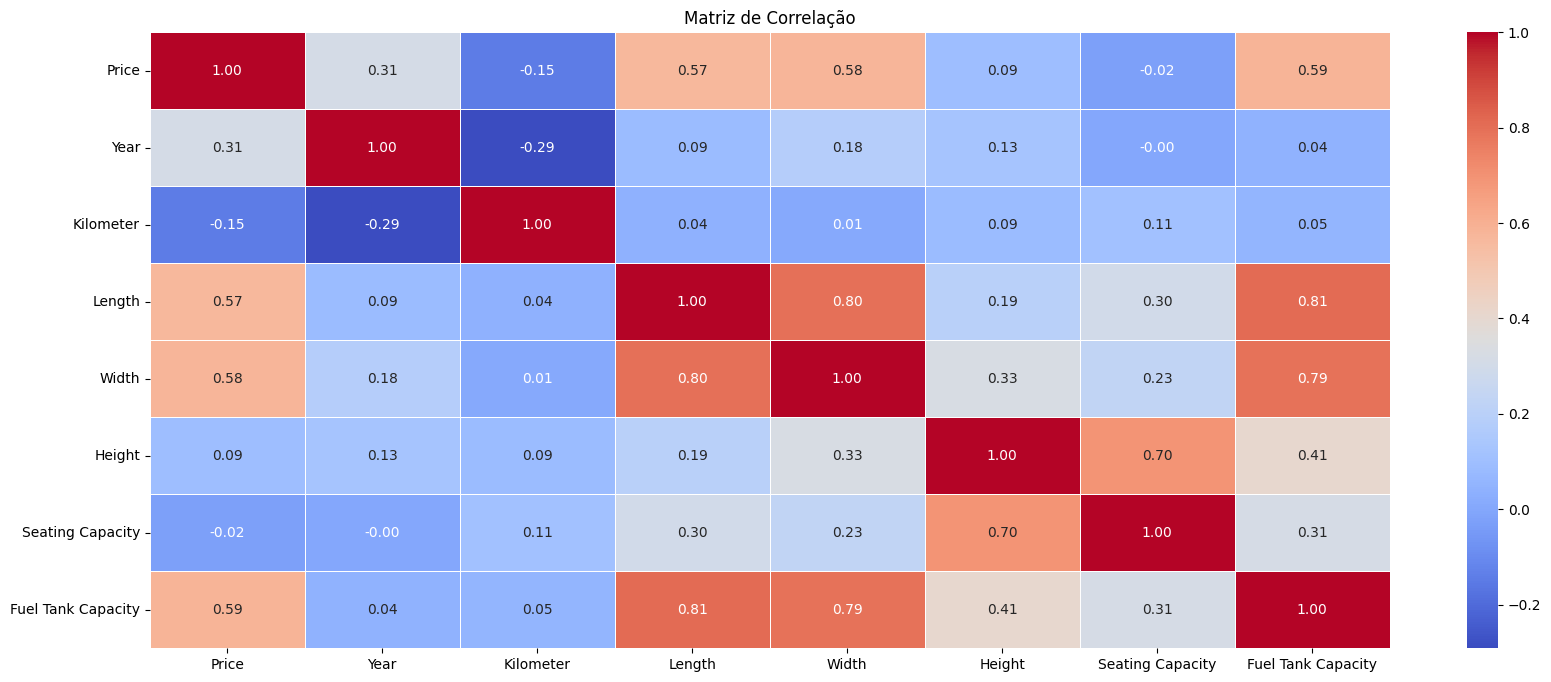

In [ ]:
# Seleciona variáveis numéricas
df_num_cars = df_car.select_dtypes(include=['float64', 'int64'])

# Calcula matriz de correlação
corr_cars = df_num_cars.corr()

# Plot
plt.figure(figsize=(20, 8))
sns.heatmap(corr_cars, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

Há **correlações positivas** entre o preço x 'length' (0.57); preço x 'width' (0.58); e preço x 'fuel tank capacity' (0.59) apesar de não serem tão fortes.

As dimensões do carro e a capacidade de armazenamento de combustível estão relacionadas positivimente com o preço. Ou seja, a medida que uma dessas variáveis aumenta, o preço tende a aumentar também.


É possível observar **correlações negativas** entre ano e quilometragem do carro (-0.29). Significando que à medida que o ano de fabricação do carro aumenta, a quilometragem tende a diminuir. Já que carros mais novos tem menos quilometros rodados.

Assim como a **correlação negativa de -0.15** entre o preço e a quilometragem, indicando que carros com menor quilometragem tendem a ter preços mais altos.

## Questão 08

8. Codifique e exiba Gráficos de Dispersão para cada uma das variáveis numéricas em relação à variável de interesse Price

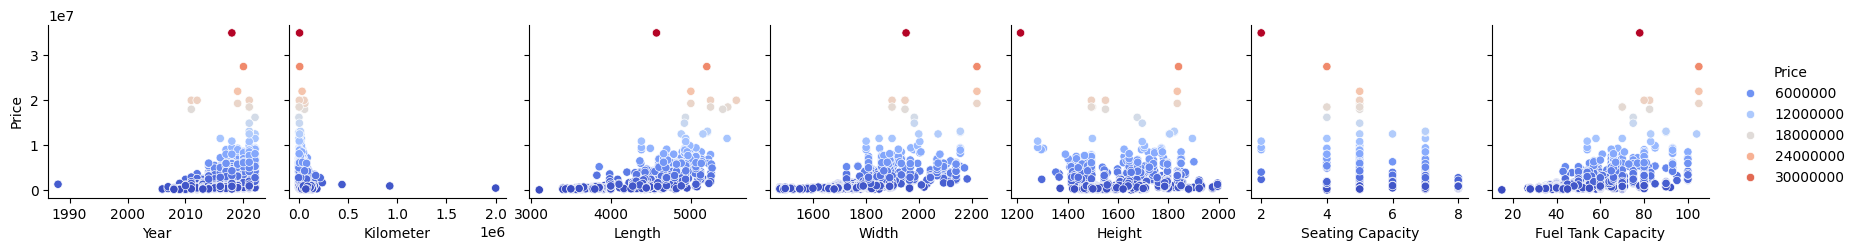

In [ ]:
# Plotando o gráfico de dispersão
sns.pairplot(df_num_cars, y_vars='Price', palette = 'coolwarm', hue='Price')
plt.show()

A partir da análise dos gráficos de dispersão, assim como observado na questão 7, há uma correlação positiva (mas fraca) entre as dimensões e capacidade de armazenamento de combustível com o preço.

## Questão 09

9. Crie um modelo de Regressão Linear Simples, exiba a Tabela de Regressão e exiba o plot da Reta Estimada.

In [ ]:
# Importanto pacote
import statsmodels.api as sm

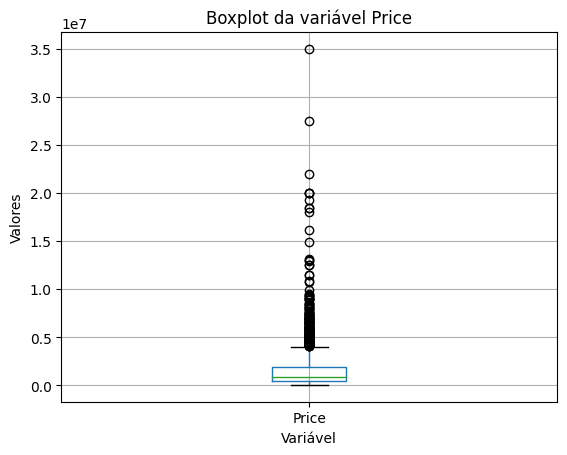

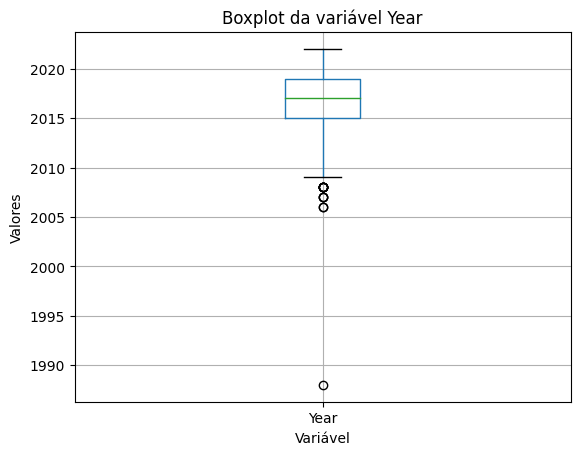

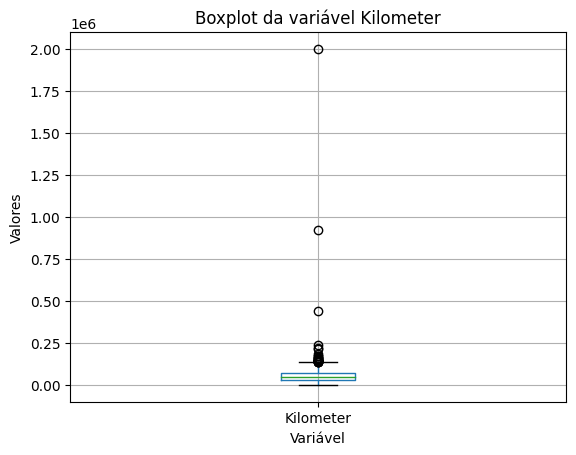

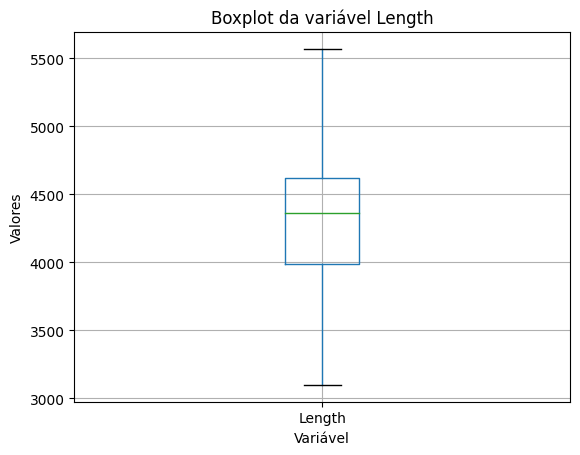

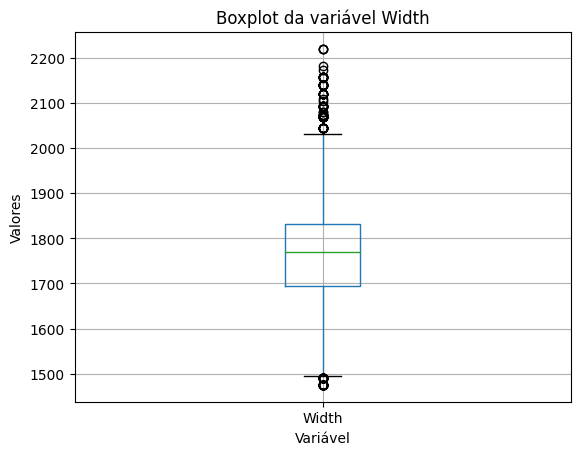

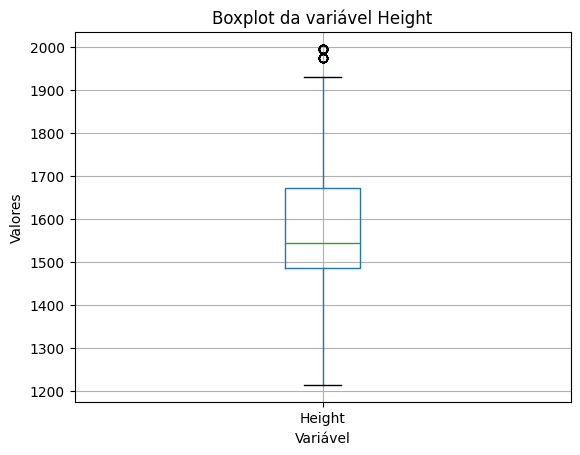

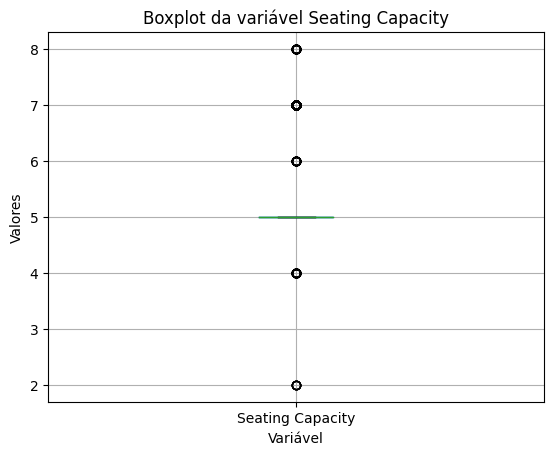

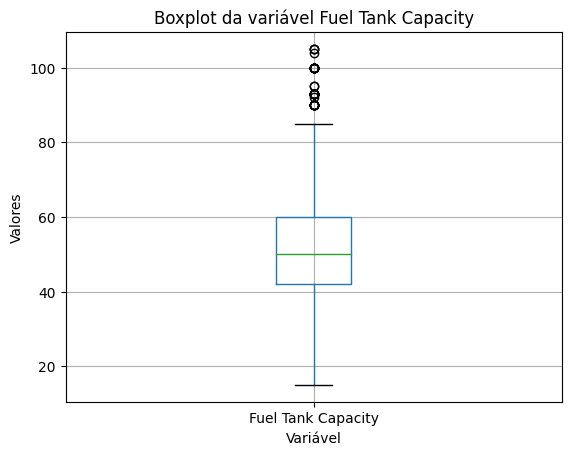

In [ ]:
# Cria uma nova figura para cada plot
for column in df_num_cars.columns:
    plt.figure()
    df_num_cars.boxplot(column=[column])
    plt.title(f'Boxplot da variável {column}')
    plt.ylabel('Valores')
    plt.xlabel('Variável')
    plt.show()

In [ ]:
# Função para calculo de regressão linear simples
def linear_regression_and_plot(X, y, y_label):
    # Adicionar constante
    X = sm.add_constant(X)

    # Ajustar modelo
    model = sm.OLS(y, X).fit()

    # Imprimir tabela de regressão
    print(model.summary())

    # Plotar gráfico da reta estimada
    plt.scatter(X.iloc[:, 1], y, label='Data')
    plt.plot(X.iloc[:, 1], model.predict(X), color='red', label='Regression Line')
    plt.title(f'Regressão Linear Simples para {y_label}')
    plt.xlabel('X')
    plt.ylabel(y_label)
    plt.legend()
    plt.show()

### Regressão Linear Price x Year

                            OLS Regression Results                            
Dep. Variable:                   Year   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     198.1
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           7.48e-43
Time:                        13:48:17   Log-Likelihood:                -4707.7
No. Observations:                1874   AIC:                             9419.
Df Residuals:                    1872   BIC:                             9430.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2016.0257      0.085   2.39e+04      0.0

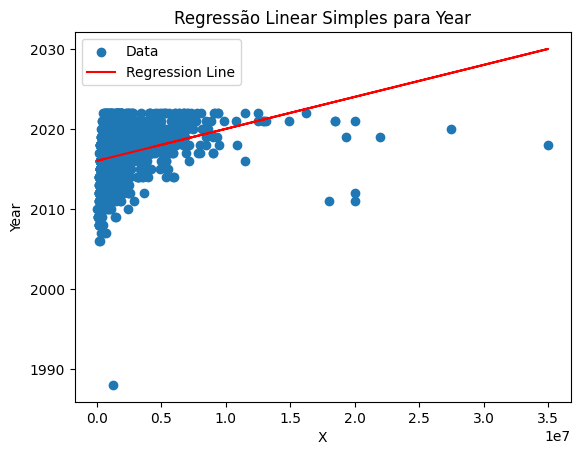

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Year']

linear_regression_and_plot(X, y, 'Year')

### Regressão Linear Price x Kilometer

                            OLS Regression Results                            
Dep. Variable:              Kilometer   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     41.50
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           1.49e-10
Time:                        13:55:21   Log-Likelihood:                -23218.
No. Observations:                1874   AIC:                         4.644e+04
Df Residuals:                    1872   BIC:                         4.645e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.931e+04   1646.565     36.021      0.0

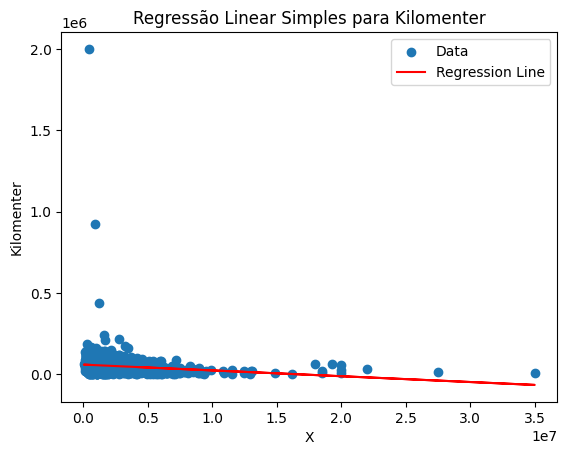

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Kilometer']

linear_regression_and_plot(X, y, 'Kilomenter')

### Regressão Linear Price x Length

                            OLS Regression Results                            
Dep. Variable:                 Length   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     895.7
Date:                Sun, 13 Oct 2024   Prob (F-statistic):          3.71e-161
Time:                        13:56:18   Log-Likelihood:                -13683.
No. Observations:                1874   AIC:                         2.737e+04
Df Residuals:                    1872   BIC:                         2.738e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4105.7569     10.159    404.149      0.0

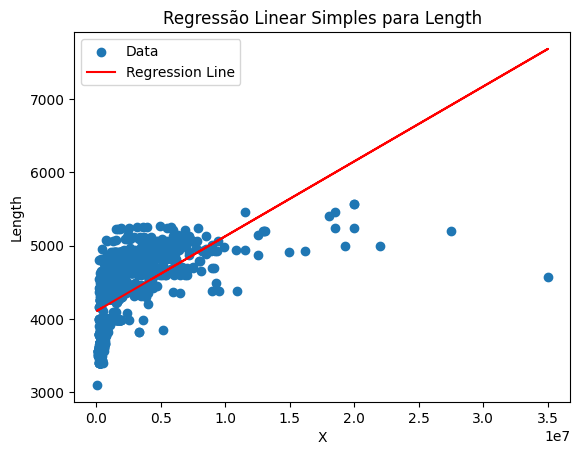

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Length']

linear_regression_and_plot(X, y, 'Length')

### Regressão Linear Price x Width

                            OLS Regression Results                            
Dep. Variable:                  Width   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     934.8
Date:                Sun, 13 Oct 2024   Prob (F-statistic):          7.23e-167
Time:                        13:57:26   Log-Likelihood:                -11420.
No. Observations:                1874   AIC:                         2.284e+04
Df Residuals:                    1872   BIC:                         2.286e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1714.2016      3.037    564.353      0.0

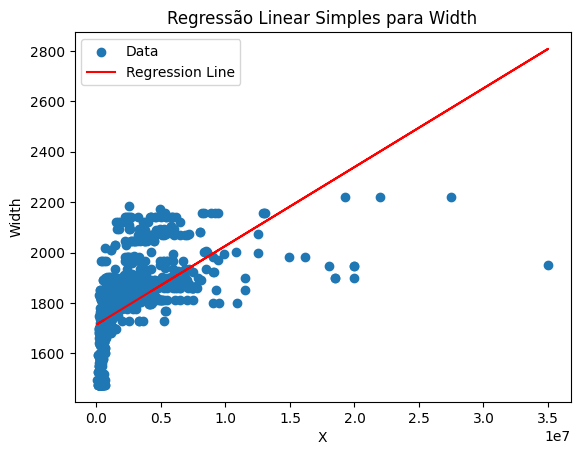

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Width']

linear_regression_and_plot(X, y, 'Width')

### Regressão Linear Simples Price x Height

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     16.32
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           5.56e-05
Time:                        13:58:21   Log-Likelihood:                -11838.
No. Observations:                1874   AIC:                         2.368e+04
Df Residuals:                    1872   BIC:                         2.369e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1580.1035      3.796    416.281      0.0

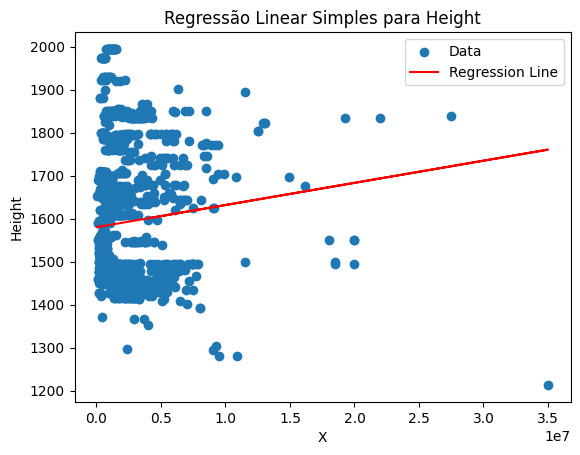

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Height']

linear_regression_and_plot(X, y, 'Height')

In [ ]:
df_num_cars.columns

Index(['Price', 'Year', 'Kilometer', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')

### Regressão Linear Simples Price x Seating Capacity

                            OLS Regression Results                            
Dep. Variable:       Seating Capacity   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.159
Date:                Sun, 13 Oct 2024   Prob (F-statistic):              0.282
Time:                        14:00:04   Log-Likelihood:                -2256.2
No. Observations:                1874   AIC:                             4516.
Df Residuals:                    1872   BIC:                             4527.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3093      0.023    232.405      0.0

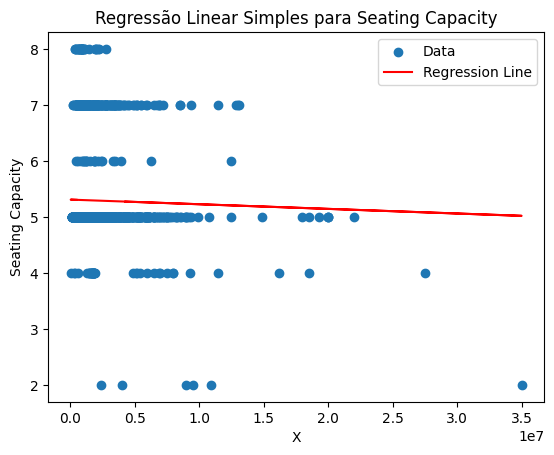

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Seating Capacity']

linear_regression_and_plot(X, y, 'Seating Capacity')

### Regressão Linear Simples Price x Fuel Tank Capacity

                            OLS Regression Results                            
Dep. Variable:     Fuel Tank Capacity   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     979.6
Date:                Sun, 13 Oct 2024   Prob (F-statistic):          2.59e-173
Time:                        14:01:03   Log-Likelihood:                -7359.9
No. Observations:                1874   AIC:                         1.472e+04
Df Residuals:                    1872   BIC:                         1.473e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.9212      0.348    131.962      0.0

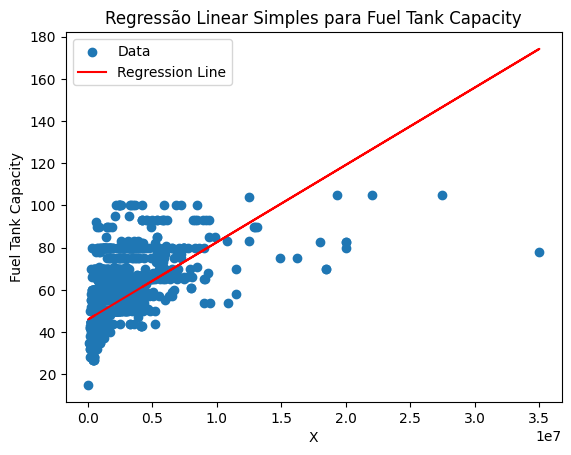

In [ ]:
X = df_num_cars['Price']
y = df_num_cars['Fuel Tank Capacity']

linear_regression_and_plot(X, y, 'Fuel Tank Capacity')

## Questão 10

10. Codifique e exiba o gráfico dos resíduos do modelo de Regressão Simples.

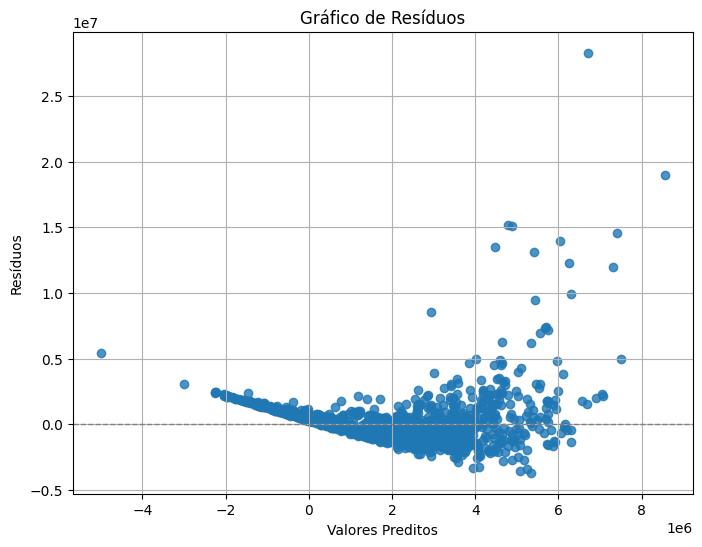

In [ ]:
# Adicionando uma coluna de uns para o termo constante
X = sm.add_constant(X)

# Ajustando o modelo de regressão simples
model = sm.OLS(y, X).fit()

# Obtendo os resíduos
residuals = model.resid

# Plotando o gráfico dos resíduos
plt.figure(figsize=(8, 6))
plt.scatter(model.predict(), residuals, alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.title('Gráfico de Resíduos')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.grid(True)
plt.show()

## Questão 11

11. Crie um modelo de Regressão Multivariada, exiba a Tabela de Regressão e exiba o gráfico dos resíduos do modelo.

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     391.4
Date:                Sun, 13 Oct 2024   Prob (F-statistic):          2.79e-197
Time:                        14:11:14   Log-Likelihood:                -29753.
No. Observations:                1874   AIC:                         5.951e+04
Df Residuals:                    1870   BIC:                         5.954e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               -1.21e+07   8.16

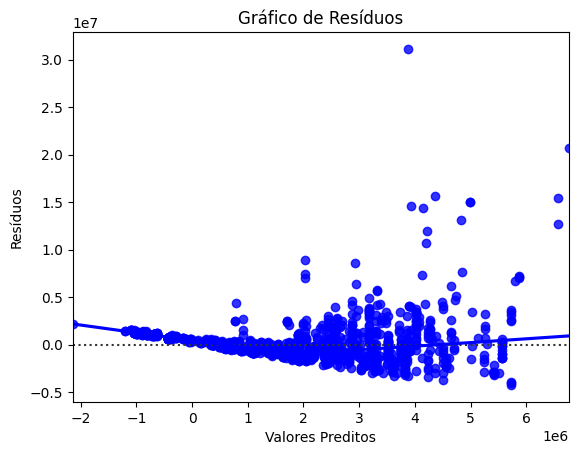

In [ ]:
# Definindo variáveis independentes (X) e variável dependente (y)
X = df_num_cars[['Fuel Tank Capacity', 'Width', 'Length']]
y = df_num_cars['Price']

# Adicionar constante ao X
X = sm.add_constant(X)

# Ajustando o modelo de regressão multivariada
model = sm.OLS(y, X).fit()

# Exibindo a tabela de regressão
print(model.summary())

# Plotando o gráfico dos resíduos
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, color='blue')
plt.title('Gráfico de Resíduos')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.show()


A partir do gráfico de resíduos, pode ser verificado:

* **Tendência não aleatória:** A linha azul (lowess) que tenta ajustar os pontos dos resíduos não está próxima da linha horizontal zero. Isso sugere que os resíduos não estão distribuídos aleatoriamente, o que viola uma das principais premissas da regressão linear.


* **Heterocedasticidade:** A dispersão dos pontos em torno da linha azul não é constante. À medida que os valores preditos aumentam, a dispersão dos resíduos também tende a aumentar. Isso indica heterocedasticidade, ou seja, a variância dos erros não é constante ao longo dos valores preditos.



Observando a tabela de regressão:

* O modelo explica 38,6% da variabilidade do preço.

* Todas as variáveis independentes ("Fuel Tank Capacity", "Width" e "Length") são estatisticamente significativas na explicação do preço.

* Os resíduos não seguem uma distribuição normal, o que pode indicar problemas com o modelo ou com os dados.

* Não há evidências de autocorrelação nos resíduos.